In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load data
data_df = pd.read_csv("data/Neville2024_sperm_mutation.tsv", sep="\t")
data_df = data_df.dropna(subset=["non_nsite", "mis_nsite", "ssite"])

# Load gene sets
DD_gene_set = [
    line.strip() for line in open("../Fig4/data/denovoWEST_DD-related_gene.lst", "r")
]
ASD_gene_set = [line.strip() for line in open("../Fig4/data/ASD-related_gene.lst", "r")]

# Annotate
data_df["is_DD"] = data_df["gene_name"].map(lambda x: x in DD_gene_set)
data_df["is_ASD"] = data_df["gene_name"].map(lambda x: x in ASD_gene_set)
data_df["is_cRDHGs"] = data_df["gene_name"].map(
    lambda x: (x.startswith("HIST")) and ("H1" not in x)
)
data_df["is_OG"] = data_df.apply(
    lambda row: (not row["is_DD"]) and (not row["is_ASD"]) and (not row["is_cRDHGs"]),
    axis=1,
)

In [3]:
df_dic_lst = []

# Calculate dN/dS for each gene type
for gene_type in ["cRDHGs", "ASD", "DD", "OG"]:

    sub_df = data_df[data_df[f"is_{gene_type}"]]
    gene_num = len(sub_df)

    nsite_mis_sum = sub_df["mis_nsite"].sum()
    nsite_non_sum = sub_df["non_nsite"].sum()
    ssite_sum = sub_df["ssite"].sum()

    mis_sum = sub_df["n_mis"].sum()
    non_sum = sub_df["n_non"].sum()
    syn_sum = sub_df["n_syn"].sum()

    dnds_mis = (mis_sum / nsite_mis_sum) / (syn_sum / ssite_sum)
    dnds_non = (non_sum / nsite_non_sum) / (syn_sum / ssite_sum)

    df_dic_lst.append(
        {
            "Gene type": gene_type,
            "Gene number": gene_num,
            "mis count": mis_sum,
            "non count": non_sum,
            "syn count": syn_sum,
            "dN/dS (Missense)": dnds_mis,
            "dN/dS (Nonsense)": dnds_non,
        }
    )

plot_df = pd.DataFrame(df_dic_lst)
plot_df["Gene type"] = plot_df["Gene type"].map(
    {
        "cRDHGs": "core RDHs",
        "OG": "Other genes",
        "DD": "DD-related",
        "ASD": "ASD-related",
    }
)

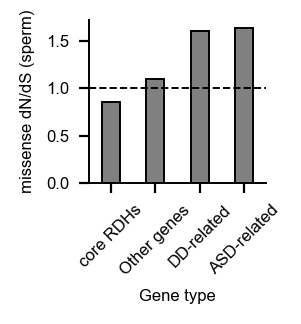

In [4]:
# Plot
fig, ax = plt.subplots(
    1, 1,
    figsize=(1.5, 1.6)
)

sns.barplot(
    data=plot_df,
    x='Gene type',
    y='dN/dS (Missense)',
    order=[
        'core RDHs',
        'Other genes',
        'DD-related',
        'ASD-related',
    ],
    color='gray',
    width=0.4,
    edgecolor='black',
    linewidth=0.7,
)

ax.xaxis.set_tick_params(rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(y=1, color='black', linestyle='--', linewidth=0.7)
ax.set_ylabel('missense dN/dS (sperm)')

plt.tight_layout()